# Example: Downloading datasets from the Climate Data Store with the `cdsapi`

## The Climate Data Store

The Climate Data Store (CDS) provides free open access to information about the past, present and future climate, including observations, historical records, reanalyses, forecasts, and projections. The CDS can be accessed online at <https://cds.climate.copernicus.eu/> or programmatically using the `cdsapi` Python package.

## Installing and configuring the `cdsapi` package

To run this example, you need a CDS account and your API key (personal access token), which is available from <https://cds.climate.copernicus.eu/how-to-api>.

Please enter your API key to configure the `cdsapi.Client` in the next cell.

Please remember that you must keep your API key private and should not share a notebook that contains your personal API key.

In [1]:
import getpass

import cdsapi

client = cdsapi.Client(
    url="https://cds.climate.copernicus.eu/api",
    key=getpass.getpass("CDS-API-KEY: "),
)

[pyodide]: Loading attrs, cdsapi, ecmwf-datastores-client, multiurl, python-dateutil, pytz, six, tqdm, typing_extensions
[pyodide]: Loaded attrs, cdsapi, ecmwf-datastores-client, multiurl, python-dateutil, pytz, six, tqdm, typing_extensions


CDS-API-KEY:  ········


/lib/python3.14/site-packages/ecmwf/datastores/client.py:88: UserWarning: Expecting value: line 1 column 1 (char 0)
  warnings.warn(str(exc), UserWarning)


## Retrieving the dataset

You can now retrieve the following example NetCDF dataset.

```{tip}
Retrieving a dataset from the Climate Data Store may take a long time to process, ranging from minutes to hours, as data requests are served on the fly using a queueing system. If you intend to reuse a dataset several times, consider downloading it to your local machine instead of fetching it from the CDS every time.
```

Once the download has completed, you should have a new `03-t2m.nc` file in the `data/` subdirectory.

In [2]:
from pathlib import Path

req = client.retrieve(
    "reanalysis-era5-single-levels",
    {
        "variable": "2t",
        "product_type": "reanalysis",
        "date": "2012-12-01",
        "time": "14:00",
        "format": "netcdf",
    },
)

data_path = req.download(Path("data") / "03-t2m.nc")

2026-09-11 14:37:02,352 INFO Request ID is 09ef54ea-9f33-4058-8101-597166a79d85
2026-09-11 14:37:02,807 INFO status has been updated to accepted
2026-09-11 14:38:19,177 INFO status has been updated to successful
[CORS]: The origin https://object-store.os-api.cci2.ecmwf.int does not support Cross-Origin Resource Sharing.
        Requests to this origin are being proxied, which may reduce performance.

        Please ask the maintainers of https://object-store.os-api.cci2.ecmwf.int to enable CORS using the
        Access-Control-Allow-Origin header.

        Please see https://developer.mozilla.org/en-US/docs/Web/HTTP/CORS for
        more information about Cross-Origin Resource Sharing.


[pyodide]: Loading ipywidgets, jupyterlab_widgets
[pyodide]: Loaded ipywidgets, jupyterlab_widgets


/lib/python3.14/site-packages/multiurl/base.py:49: TqdmMonitorWarning: tqdm:disabling monitor support (monitor_interval = 0) due to:
can't start new thread
  return tqdm(


d36bc855f88f6b3ebca76b2d3dcfcdb9.nc:   0%|          | 0.00/1.46M [00:00<?, ?B/s]

[pyodide]: Memory usage has grown to 51.9MiB (from 43.2MiB) for this notebook


In [3]:
import xarray as xr

ds = xr.open_dataset(data_path)
ds

[pyodide]: Loading numpy, pandas, tzdata, xarray
[pyodide]: Loaded numpy, pandas, tzdata, xarray
[pyodide]: Loading pyarrow, pyodide-unix-timezones
[pyodide]: Loaded pyarrow, pyodide-unix-timezones
[pyodide]: Loading cloudpickle
[pyodide]: Loaded cloudpickle
[pyodide]: Loading Bottleneck
[pyodide]: Loaded Bottleneck
[pyodide]: Loading cftime
[pyodide]: Loaded cftime
[pyodide]: Loading PyYAML, click, dask, fsspec, locket, partd, toolz
[pyodide]: Loaded PyYAML, click, dask, fsspec, locket, partd, toolz
[pyodide]: Loading netCDF4
[pyodide]: Loaded netCDF4
[pyodide]: Loading h5netcdf
[pyodide]: Loaded h5netcdf
[pyodide]: Loading Jinja2, MarkupSafe, WebOb, beautifulsoup4, cattrs, legacy-cgi, lxml, platformdirs, pydap, requests-cache, scipy, soupsieve, url-normalize
[pyodide]: Loaded Jinja2, MarkupSafe, WebOb, beautifulsoup4, cattrs, legacy-cgi, lxml, platformdirs, pydap, requests-cache, scipy, soupsieve, url-normalize
[pyodide]: Loading Deprecated, donfig, google-crc32c, numcodecs, wrapt, z

/lib/python3.14/site-packages/earthkit/data/core/config.py:287: UserWarning: only soft file lock is available
  from filelock import FileLock


[pyodide]: Loading MetPy, contourpy, cycler, fonttools, kiwisolver, matplotlib, pillow, pooch, pyparsing, pyproj
[pyodide]: Loaded MetPy, contourpy, cycler, fonttools, kiwisolver, matplotlib, pillow, pooch, pyparsing, pyproj
[pyodide]: Loading uncertainties
[pyodide]: Loaded uncertainties
[pyodide]: Loading Cartopy, pyshp, shapely
[pyodide]: Loaded Cartopy, pyshp, shapely
[pyodide]: Loading click-plugins, cligj, fiona
[pyodide]: Loaded click-plugins, cligj, fiona
[pyodide]: Loading boto3, botocore, jmespath, s3transfer
[pyodide]: Loaded boto3, botocore, jmespath, s3transfer
[pyodide]: Loading kerchunk, ujson
[pyodide]: Loaded kerchunk, ujson
[pyodide]: Loading crc32c
[pyodide]: Loaded crc32c
[pyodide]: Loading msgpack
[pyodide]: Loaded msgpack
[pyodide]: Loading pathlib_abc, universal_pathlib
[pyodide]: Loaded pathlib_abc, universal_pathlib
[pyodide]: Loading lz4
[pyodide]: Loaded lz4


<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2012-12-01T14:00:00
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    expver      <U4 16B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-18T11:06 GRIB to CDM+CF via cfgrib-0.9.1...

[pyodide]: Memory usage has grown to 268.7MiB (from 51.9MiB) for this notebook
[pyodide]: Loaded 197 new dynamic libraries (200 total for this notebook)


## Plotting the dataset

In [4]:
import sys

sys.path.insert(0, "../..")

In [5]:
import utils

We finally plot the loaded dataset, here the 2 metre temperature variable `t2m`, using `earthkit.plots`:

[pyodide]: Loading adjustText, earthkit-plots, narwhals, plotly
[pyodide]: Loaded adjustText, earthkit-plots, narwhals, plotly
[pyodide]: Loading earthkit-plots-default-styles
[pyodide]: Loaded earthkit-plots-default-styles


/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


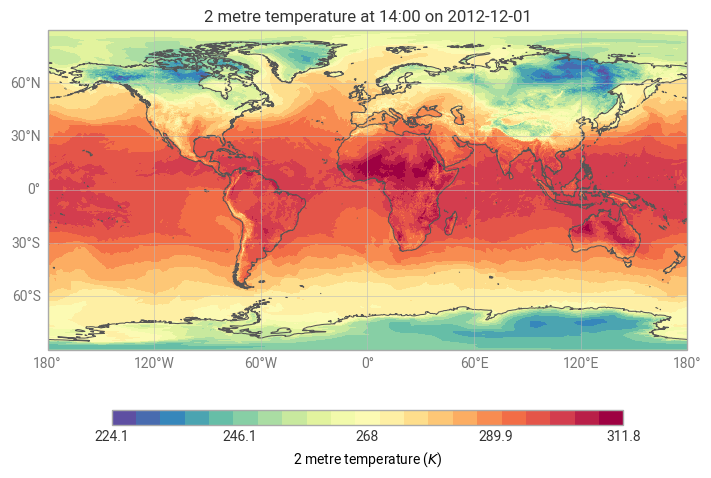

[pyodide]: Memory usage has grown to 557.2MiB (from 268.7MiB) for this notebook
[pyodide]: Loaded 2 new dynamic libraries (202 total for this notebook)


In [6]:
utils.quickplot(ds["t2m"])